# Deep Learning Regression — *Predicting Log House Price from Four Covariates*

In notebook 01 we predicted consumption from income with a
straight line. Log house price is harder: amenity scores
interact with distance-to-CBD, and building age has a
sweet-spot (very old heritage homes price up, mid-old ones
price down). A **neural network** can learn that bend.

## The story, extended

Each row is one transacted property, summarised by four
covariates `f1, f2, f3, f4` (floor area, amenity score,
distance-to-CBD penalty, building age) and one target `y` —
the log sale price on a 0–10 scale. The covariates interact:
the `f2 · f3` (amenity × distance) product reflects the
location premium, and `f4` has a non-monotone effect.

## Glossary — your field ↔ ML

Mental bridge for the deep-learning notebook. Here `f1, f2, f3, f4` are
four **house-level covariates** — say floor area (`f1`), neighbourhood
amenity score (`f2`), distance-to-CBD penalty (`f3`), and building age
(`f4`) — and **`y` is the predicted log house price** on a 0–10 scale.

| Your field | ML term | Short bridge |
|------------|---------|--------------|
| A vector of property covariates per house | feature vector | Multiple regressors combined into one prediction. |
| The log-price target | target | The dependent variable. |
| A flexible hedonic price model | neural network | Stack of simple computations learning a smooth function. |
| Each "perceptron" combining covariates | hidden layer | Intermediate stage in the network. |
| A nonlinear squashing applied per node | activation function | The curvy step that lets the network bend. |
| A piecewise-linear "off below 0, on above" | ReLU | Cheapest, most popular nonlinearity. |
| Computing a predicted log-price from covariates | forward pass | Pushing inputs through the network. |
| Working out which covariate weights to nudge | backward pass / backpropagation | Computing the gradient of the loss. |
| The optimisation routine that updates weights (Adam here) | optimizer | Decides how to use the gradient. |
| A handful of houses processed together each step | batch | One mini-update of the weights. |
| Why hedonic pricing is not linear in the covariates | non-linearity | Real price surfaces curve and interact. |

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
rng = np.random.default_rng(0)

## 1. The data

Each row is one past house. The four columns are the
covariate **features** `f1, f2, f3, f4` (rescaled to 0–1) and
the column we want to predict is the **target** log price `y`.

### From one feature to many

We now have a feature *vector* per observation, not a single number.
The model still produces one **prediction** per observation; it just
has more inputs to combine.

### In your field

Each row is one housing transaction. The four **features**
`f1, f2, f3, f4` are floor area, amenity score, distance-to-CBD
penalty, and building age (rescaled to 0–1) and the **target** `y`
is log house price on a 0–10 scale. A hedonic regression handles
the same inputs.

In [2]:
N = 800
X = rng.uniform(0, 1, size=(N, 4)).astype(np.float32)
f1, f2, f3, f4 = X[:, 0], X[:, 1], X[:, 2], X[:, 3]

# Non-linear ground truth: a smooth function with interactions.
y_true = (
    5.0
    + 3.0 * np.sin(2 * np.pi * f1)
    + 4.0 * (f2 * f3)
    - 6.0 * (f4 - 0.4) ** 2
    + rng.normal(0, 0.3, size=N).astype(np.float32)
)
y = y_true.astype(np.float32)
X.shape, y.shape

((800, 4), (800,))

A linear hedonic model cannot capture this — log price is not
a straight-line function of any single covariate. We need a
model that bends, and that learns *interactions* between
covariates, the way a non-parametric or semi-parametric
hedonic regression must.

### Go deeper with an LLM (optional — skip if you already know this)

**Prompt 1 — why nonlinearity matters**
```
Explain in plain words why a linear hedonic regression cannot
capture the way amenity scores interact with distance-to-CBD,
but a small neural network with ReLU activations can. Give a
two-covariate toy example. Keep the answer to ~5 minutes of
reading so I can return to my notebook.
```

**Prompt 2 — hidden layers as covariate interactions**
```
A "hidden layer" in a neural network mixes input features into
intermediate variables. If my inputs are four house-level
covariates, what kinds of mixtures might a hidden layer
discover that look like the interaction terms an applied
economist would put in by hand? Keep the answer to ~5 minutes
of reading so I can return to my notebook.
```

## 2. The model — a small neural network

A **neural network** stacks layers of simple computations.
Each **hidden layer** computes `h = activation(W · x + b)`, where
`W` and `b` are learnable **weights** and **bias** and the
**activation function** is a **non-linearity** such as **ReLU**
($\text{ReLU}(z) = \max(0, z)$). Without an activation function,
stacking layers would still only give you a linear model.

Our network has 4 inputs → 16 hidden units → 16 hidden units → 1
output (the predicted target).

### In your field

Each **hidden layer** is a stack of basis functions the network
learns by itself — combinations like "newer building *and* close to
CBD" that a hedonic specialist might have built by hand using
splines or interaction terms. The **non-linearity** between layers
is what lets the network bend in ways a fixed cubic spline cannot.

### Worked example

Each hidden unit is like one virtual appraiser paying
attention to a particular combination of covariates — "high
amenity *and* close to CBD", say. The next layer pools the
appraisers' opinions into a final log price, much like a
spline-on-spline hedonic model combines piecewise terms.

In [3]:
class RegressionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.layers(x).squeeze(-1)

net = RegressionNet()
sum(p.numel() for p in net.parameters())   # total parameters

369

## 3. Training — forward pass, loss, backward pass

Training one **batch** of data has three steps:

1. **Forward pass** — feed the features through the network to get
   predictions.
2. Compute the **loss** (MSE again) by comparing predictions to
   targets.
3. **Backward pass** (also called **backpropagation**) — compute
   the **gradient** of the loss with respect to every weight, then
   ask the **optimizer** to nudge the weights one step.

We repeat for many **epochs** until the loss stops improving.

### In your field

The **forward pass** is "given a property's four attributes,
predict its log price"; the **backward pass / backpropagation** is
"work out how to nudge every weight so the prediction gets closer
to the observed price"; the **optimizer** (Adam) applies the
nudges. One **batch** is a chunk of transactions processed
together — much like estimating in subsamples.

In [4]:
# Train/test split.
idx = rng.permutation(N)
n_train = int(0.8 * N)
train_idx, test_idx = idx[:n_train], idx[n_train:]

X_train = torch.tensor(X[train_idx])
y_train = torch.tensor(y[train_idx])
X_test  = torch.tensor(X[test_idx])
y_test  = torch.tensor(y[test_idx])

In [5]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(net.parameters(), lr=1e-2)

epochs = 300
batch_size = 64
history = []

for epoch in range(epochs):
    perm = torch.randperm(X_train.shape[0])
    epoch_loss = 0.0
    for start in range(0, X_train.shape[0], batch_size):
        b = perm[start:start + batch_size]
        pred = net(X_train[b])                  # forward pass
        loss = loss_fn(pred, y_train[b])
        optimizer.zero_grad()
        loss.backward()                          # backward pass
        optimizer.step()
        epoch_loss += float(loss) * b.shape[0]
    history.append(epoch_loss / X_train.shape[0])

print(f"final train MSE = {history[-1]:.3f}")

/var/folders/b7/h15h1tz12pbccr7tnv5wf8ym0000gn/T/ipykernel_59311/3561324963.py:18: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  epoch_loss += float(loss) * b.shape[0]


final train MSE = 0.184


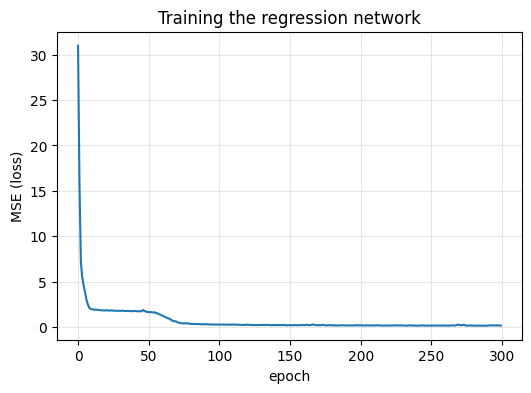

In [6]:
# Loss curve — average MSE per epoch over our batches of houses.

plt.figure(figsize=(6, 4))
plt.plot(history)
plt.xlabel("epoch")
plt.ylabel("MSE (loss)")
plt.title("Training the regression network")
plt.grid(True, alpha=0.3)
plt.show()

### Go deeper with an LLM (optional — skip if you already know this)

**Prompt 1 — forward and backward pass**
```
Walk me through one training step of a small neural network:
forward pass, MSE loss, backward pass, optimizer step. Use a
tiny example with four house covariates as inputs and log
price as output. Keep the answer to ~5 minutes of reading so
I can return to my notebook.
```

**Prompt 2 — Adam vs Newton/BHHH**
```
What does the Adam optimizer do that plain stochastic gradient
descent does not? Frame the answer for someone used to Newton
or BHHH steps in econometrics. Keep the answer to ~5 minutes
of reading so I can return to my notebook.
```

## 4. Did it actually learn?

We now look at the **test data** the network has never seen.
If the test MSE is close to the training MSE, the model has learned
a generalisable rule, not just memorised. If the test MSE is much
higher, we have **overfitting** — the same enemy as in notebook 01,
only sneakier in deep models with many parameters.

### In your field

**Overfitting** in a hedonic neural network means the model memorises
transaction-level idiosyncrasies — perhaps the buyer-specific
discounts in your panel — instead of learning a stable price
surface. The warning sign is the same one you watch when running a
flexible nonparametric regression: in-sample fit improves while
out-of-sample loss stalls.

test MSE = 0.161


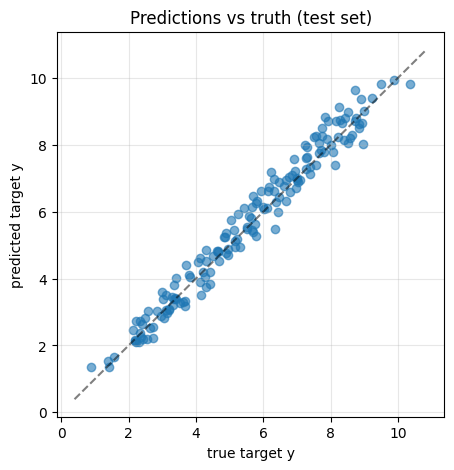

In [7]:
with torch.no_grad():
    test_pred = net(X_test)
    test_mse = float(loss_fn(test_pred, y_test))
print(f"test MSE = {test_mse:.3f}")

plt.figure(figsize=(5, 5))
plt.scatter(y_test.numpy(), test_pred.numpy(), alpha=0.6)
lims = [float(y_test.min()) - 0.5, float(y_test.max()) + 0.5]
plt.plot(lims, lims, "k--", alpha=0.5)
plt.xlabel("true target y")
plt.ylabel("predicted target y")
plt.title("Predictions vs truth (test set)")
plt.grid(True, alpha=0.3)
plt.show()

Points clustered along the diagonal mean the network has
captured the covariate interactions and the sweet-spot in
`f4`. A linear hedonic regression on the same houses would
leave a much messier scatter — and would systematically miss
the bend at the heritage-age end.

### Go deeper with an LLM (optional — skip if you already know this)

**Prompt 1 — overfitting in hedonic ML models**
```
What does "overfitting" look like specifically in a flexible
hedonic-pricing neural network trained on a small sample of
transactions? Give a concrete sign that a model is memorising
its training set rather than learning generalisable price
relations. Keep the answer to ~5 minutes of reading so I can
return to my notebook.
```

## Try this yourself

1. Reduce the network to a single `nn.Linear(4, 1)` (no hidden
   layer, no activation function). How much worse is the test
   MSE? Why is this exactly equivalent to OLS on the four
   covariates?
2. Increase the learning rate to `0.5`. What happens to the
   loss curve? Relate it to taking unrealistically large
   Newton steps in a nonlinear estimator.
3. Replace `nn.ReLU()` with `nn.Tanh()`. Does it train as well?

## Recap — vocabulary you now own

On top of notebook 01: **neural network**, **hidden layer**,
**activation function**, **ReLU**, **forward pass**,
**backward pass**, **backpropagation**, **optimizer**, **batch**,
**non-linearity**.

The training loop — forward, loss, backward, step — is the
same loop that powers every modern model, from a
four-covariate hedonic predictor like this one to the
multi-billion-parameter networks at the heart of modern
structural ML papers.